In [1]:
!unzip project_data.zip

Archive:  project_data.zip
  inflating: tokenizer_en/tokenizer_config.json  
  inflating: parallel_en_fr_corpus/test/state.json  
  inflating: parallel_en_fr_corpus/validation/dataset.arrow  
  inflating: tokenizer_fr/special_tokens_map.json  
  inflating: tokenizer_fr/tokenizer_config.json  
  inflating: parallel_en_fr_corpus/train/dataset_info.json  
  inflating: parallel_en_fr_corpus/validation/dataset_info.json  
  inflating: parallel_en_fr_corpus/test/dataset_info.json  
  inflating: tokenizer_en/special_tokens_map.json  
  inflating: parallel_en_fr_corpus/train/state.json  
  inflating: tokenizer_en/tokenizer.json  
  inflating: parallel_en_fr_corpus/train/dataset.arrow  
  inflating: tokenizer_fr/tokenizer.json  
  inflating: parallel_en_fr_corpus/validation/state.json  
  inflating: parallel_en_fr_corpus/dataset_dict.json  
  inflating: parallel_en_fr_corpus/test/dataset.arrow  


In [2]:
from datasets import load_from_disk

ds = load_from_disk("parallel_en_fr_corpus/train")

print("Columns:", ds.column_names)
print("First row ex:", ds[0])

Columns: ['text_en', 'text_fr']
First row ex: {'text_en': 'i m tough .', 'text_fr': 'je suis dure .'}


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import PreTrainedTokenizerFast
from datasets import load_from_disk

class TranslationDataset(Dataset):
    def __init__(self, dataset_path, split, src_tokenizer, trg_tokenizer, src_lang="fr", trg_lang="en"):

        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

        self.src_key = "text_fr"
        self.trg_key = "text_en"

        print(f"Loading {split} data from disk...")
        full_path = f"{dataset_path}/{split}"
        self.hf_dataset = load_from_disk(full_path) #open data file

    #total number of sentences
    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sentences = self.hf_dataset[idx]

        #get sentences using idx
        src_sent = sentences[self.src_key]
        trg_sent = sentences[self.trg_key]

        # Tokenize (text -> list of IDs)
        src_ids = self.src_tokenizer.encode(src_sent,add_special_tokens=False)
        trg_ids = self.trg_tokenizer.encode(trg_sent,add_special_tokens=False)

        # Add Special Tokens: [BOS] + IDs + [EOS]
        src_tensor = torch.tensor([self.src_tokenizer.bos_token_id] + src_ids + [self.src_tokenizer.eos_token_id], dtype=torch.long)
        trg_tensor = torch.tensor([self.trg_tokenizer.bos_token_id] + trg_ids + [self.trg_tokenizer.eos_token_id], dtype=torch.long)

        return src_tensor, trg_tensor

#force every sentence in the batch to be the same length by adding padding to the end of the short ones.
def padding(batch,pad_idx):
    src_batch, trg_batch = [], []
    for src, trg in batch:
        src_batch.append(src)
        trg_batch.append(trg)

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=pad_idx)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=pad_idx)

    return src_padded, trg_padded

def get_data_loaders(dataset_path, src_tokenizer, trg_tokenizer, batch_size=64):

    pad_idx = trg_tokenizer.pad_token_id

    # 1. Create Datasets
    train_dataset = TranslationDataset(dataset_path, "train", src_tokenizer, trg_tokenizer)
    valid_dataset = TranslationDataset(dataset_path, "validation", src_tokenizer, trg_tokenizer)
    test_dataset = TranslationDataset(dataset_path, "test", src_tokenizer, trg_tokenizer)

    # 2. Create Loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    print("Loading tokenizers...")
    try:
        tokenizer_fr = PreTrainedTokenizerFast.from_pretrained("tokenizer_fr")
        tokenizer_en = PreTrainedTokenizerFast.from_pretrained("tokenizer_en")

    except Exception as e:
        print(f"Error: {e}")
        exit()

    print(f"SRC_VOCAB_SIZE (French): {len(tokenizer_fr)}")
    print(f"TGT_VOCAB_SIZE (English): {len(tokenizer_en)}")
    print(f"BOS_IDX: {tokenizer_en.bos_token_id}")
    print(f"EOS_IDX: {tokenizer_en.eos_token_id}")
    print(f"PAD_IDX: {tokenizer_en.pad_token_id}")
    print("="*30 + "\n")

    train_loader, val_loader, test_loader = get_data_loaders(
        dataset_path="parallel_en_fr_corpus",
        src_tokenizer=tokenizer_fr,
        trg_tokenizer=tokenizer_en,
        #batch_size=64
        batch_size=32
    )

    print("ALL LOADERS READY!")

    print("testing..")
    src_batch, trg_batch = next(iter(train_loader))
    #batch size,longest sentence
    print(f"Batch Shape: {src_batch.shape}")
    print(f"Batch Shape: {trg_batch.shape}")


Loading tokenizers...
SRC_VOCAB_SIZE (French): 3200
TGT_VOCAB_SIZE (English): 3200
BOS_IDX: 1
EOS_IDX: 2
PAD_IDX: 3

Loading train data from disk...
Loading validation data from disk...
Loading test data from disk...
ALL LOADERS READY!
testing..
Batch Shape: torch.Size([32, 14])
Batch Shape: torch.Size([32, 11])


# LSTM part

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, List
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# Hyperparameters used
# ---------------------------
EMBED_SIZE = 256    # d
HIDDEN_SIZE = 512   # h (decoder hidden size)
ENC_HIDDEN = HIDDEN_SIZE  # NOTE: encoder is bidirectional -> outputs 2*h
ENC_BIDIRECTIONAL = True
ENC_NUM_LAYERS = 1  # or 2
LSTM_DROPOUT = 0.3
BATCH_SIZE = 32    # used above already
LEARNING_RATE = 0.001
MAX_EPOCHS = 10


# These are set according to previous dataset o/p:
SRC_VOCAB_SIZE = 3200  # French vocab size
TRG_VOCAB_SIZE = 3200  # English vocab size
PAD_IDX = 3
BOS_IDX = 1
EOS_IDX = 2


Using device: cuda


In [5]:
def manual_lstm_step(x_t, h_prev, c_prev, W, U, b):
    # 1. Compute all gates at once: xW + hU + b
    # Result shape: (Batch, 4 * Hidden_Dim)
    gates = x_t @ W + h_prev @ U + b

    # 2. Split into i,f,o,g
    i_gate, f_gate, o_gate, g_gate = gates.chunk(4, dim=1)

    # 3. Apply Activations
    i = torch.sigmoid(i_gate)
    f = torch.sigmoid(f_gate)
    o = torch.sigmoid(o_gate)
    g = torch.tanh(g_gate)

    # 4. Compute new Cell State (c_t) and Hidden State (h_t)
    c_t = f * c_prev + i * g
    h_t = o * torch.tanh(c_t)

    return h_t, c_t

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, enc_hidden, dropout=0.3, pad_idx=0):
        super().__init__()
        self.enc_hidden = enc_hidden
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)

        # --- FORWARD LSTM Weights --- (learnable tensors)
        self.W_f = nn.Parameter(torch.Tensor(embed_size, 4 * enc_hidden))
        self.U_f = nn.Parameter(torch.Tensor(enc_hidden, 4 * enc_hidden))
        self.b_f = nn.Parameter(torch.zeros(4 * enc_hidden))

        # --- BACKWARD LSTM Weights ---
        self.W_b = nn.Parameter(torch.Tensor(embed_size, 4 * enc_hidden))
        self.U_b = nn.Parameter(torch.Tensor(enc_hidden, 4 * enc_hidden))
        self.b_b = nn.Parameter(torch.zeros(4 * enc_hidden))

        self.dropout = nn.Dropout(dropout)
        self._init_weights() #to fill them with random dist(small)

    def _init_weights(self):
        stdv = 1.0 / math.sqrt(self.enc_hidden)
        for p in [self.W_f, self.U_f, self.b_f, self.W_b, self.U_b, self.b_b]:
            p.data.uniform_(-stdv, stdv)

    def forward(self, src, src_lengths=None):
        # src: (Batch, Seq_Len)
        batch_size, seq_len = src.size()
        embedded = self.dropout(self.embed(src)) #look up the vector for every word in the batch

        device = src.device

        # Initialize States for back and forward(there is no word before the first one)
        h_f = torch.zeros(batch_size, self.enc_hidden).to(device)
        c_f = torch.zeros(batch_size, self.enc_hidden).to(device)
        h_b = torch.zeros(batch_size, self.enc_hidden).to(device)
        c_b = torch.zeros(batch_size, self.enc_hidden).to(device)

        outputs_forward = []
        outputs_backward = []

        # Manual Loop
        for t in range(seq_len):
            # Forward Pass
            x_f = embedded[:, t, :]
            h_f, c_f = manual_lstm_step(x_f, h_f, c_f, self.W_f, self.U_f, self.b_f)
            outputs_forward.append(h_f)

            # Backward Pass (Seq_Len - 1 - t) (t=0 is the last word)
            x_b = embedded[:, seq_len - 1 - t, :]
            h_b, c_b = manual_lstm_step(x_b, h_b, c_b, self.W_b, self.U_b, self.b_b)
            outputs_backward.insert(0, h_b)

        # Stack results
        out_f = torch.stack(outputs_forward, dim=1)
        out_b = torch.stack(outputs_backward, dim=1)

        # Concatenate forward and backward
        encoder_outputs = torch.cat((out_f, out_b), dim=2)

        # Final States
        h_n = torch.stack([h_f, h_b], dim=0)
        c_n = torch.stack([c_f, c_b], dim=0)

        return encoder_outputs, (h_n, c_n)

In [7]:
# ---------------------------
# Additive Attention (Bahdanau)
# ---------------------------
class AdditiveAttention(nn.Module):
    """
    Vectorized additive attention:
    e_{t,i} = v^T tanh(W_a s_{t-1} + U_a h_i)
    where:
      - s_{t-1}: decoder hidden state (batch, h)
      - h_i: encoder outputs (batch, src_len, 2h)
    Returns:
      - context: (batch, 2h)
      - attn_weights: (batch, src_len)
    """
    def __init__(self, dec_hidden: int, enc_out_dim: int):  # enc_out_dim = 2*h
        super().__init__()
        self.Wa = nn.Linear(dec_hidden, dec_hidden, bias=False)   # maps s_{t-1} -> Rh
        self.Ua = nn.Linear(enc_out_dim, dec_hidden, bias=False)  # maps h_i -> Rh
        self.v = nn.Linear(dec_hidden, 1, bias=False)             # v^T (maps Rh -> scalar)
    def forward(self, s_prev: torch.Tensor, encoder_outputs: torch.Tensor, mask: torch.Tensor = None):
        # s_prev: (batch, dec_hidden)
        # encoder_outputs: (batch, src_len, enc_out_dim)
        # mask: (batch, src_len) with 1 for real tokens and 0 for PAD
        batch, src_len, _ = encoder_outputs.size()
        # compute term1 = Wa(s_prev) -> (batch, 1, dec_hidden)
        term1 = self.Wa(s_prev).unsqueeze(1)  # (batch, 1, dec_hidden)
        # compute term2 = Ua(h_i) -> (batch, src_len, dec_hidden)
        term2 = self.Ua(encoder_outputs)     # (batch, src_len, dec_hidden)
        # sum, apply tanh, then v^T
        # energy: (batch, src_len, 1) -> squeeze -> (batch, src_len)
        energy = self.v(torch.tanh(term1 + term2)).squeeze(-1)  # (batch, src_len)
        if mask is not None:
            # mask: 1 for valid positions, 0 for PAD. We set very negative where mask==0
            energy = energy.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(energy, dim=1)  # (batch, src_len)
        # context: weighted sum over encoder_outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, enc_out_dim)
        return context, attn_weights  # (batch, 2h), (batch, src_len)

In [8]:
class Decoder(nn.Module):
    def __init__(self, trg_vocab_size, embed_size, dec_hidden, enc_out_dim, pad_idx, dropout=0.3):
        super().__init__()
        self.dec_hidden = dec_hidden
        self.embed = nn.Embedding(trg_vocab_size, embed_size, padding_idx=pad_idx)

        # Decoder Input to LSTM is = Embedding + Context Vector
        self.lstm_input_dim = embed_size + enc_out_dim

        # --- DECODER LSTM Weights ---
        self.W = nn.Parameter(torch.Tensor(self.lstm_input_dim, 4 * dec_hidden))
        self.U = nn.Parameter(torch.Tensor(dec_hidden, 4 * dec_hidden))
        self.b = nn.Parameter(torch.zeros(4 * dec_hidden))


        # We concatenate 3 things for the final decision to give the model max info:
        # 1. Hidden State (h_t) - Current thought
        # 2. Context Vector (c_t) - What we looked at in French
        # 3. Input Embedding (y_t-1) - The previous English word
        self.W_out = nn.Linear(dec_hidden + enc_out_dim + embed_size, trg_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        stdv = 1.0 / math.sqrt(self.dec_hidden)
        for p in [self.W, self.U, self.b]:
            p.data.uniform_(-stdv, stdv)

    def forward_step(self, y_prev_emb, context, hidden):
        # hidden is a tuple (h, c)
        h_prev, c_prev = hidden

        # Ensure shape is (Batch, Hidden) for matrix math
        if h_prev.dim() == 3: h_prev = h_prev.squeeze(0)
        if c_prev.dim() == 3: c_prev = c_prev.squeeze(0)

        # 1. Concatenate Embedding + Context
        lstm_input = torch.cat([y_prev_emb, context], dim=1)

        # 2. Manual Step
        h_t, c_t = manual_lstm_step(lstm_input, h_prev, c_prev, self.W, self.U, self.b)

        # 3. Output Projection
        concat = torch.cat([h_t, context, y_prev_emb], dim=1)
        logits = self.W_out(concat)

        # 4. Return new states (unsqueeze to match expected state dimensions)
        return logits, (h_t.unsqueeze(0), c_t.unsqueeze(0)), h_t

In [9]:
# ---------------------------
# Seq2Seq wrapper
# ---------------------------
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, attention: AdditiveAttention, decoder: Decoder,
                 enc_hidden: int, dec_hidden: int, device: torch.device):
        super().__init__()
        self.encoder = encoder
        self.attention = attention
        self.decoder = decoder
        self.enc_hidden = enc_hidden  # per-direction encoder hidden size
        self.dec_hidden = dec_hidden
        # W_init: project [h_forward_last; h_backward_last] -> dec_hidden (tanh)
        # For LSTM we have both hidden and cell states; we project both separately
        self.W_init_h = nn.Linear(2 * enc_hidden, dec_hidden)
        self.W_init_c = nn.Linear(2 * enc_hidden, dec_hidden)
        self.device = device
        self.to(device)

    def init_decoder_states(self, enc_h: torch.Tensor, enc_c: torch.Tensor):
        """
        enc_h, enc_c: tensors from encoder h_n and c_n
          shapes: (num_layers * num_directions, batch, enc_hidden)
        For num_layers=1, num_directions=2:
          enc_h: (2, batch, enc_hidden) -> we want forward_last, backward_last
        We'll take the last layer's forward and backward states, concatenate, and project.
        Returns:
           hidden, cell: each (num_layers, batch, dec_hidden)
        """
        num_layers_dirs, batch, enc_hsz = enc_h.size()
        num_layers = num_layers_dirs // 2
        # extract last layer states
        # indexing formula: layer_i * num_dirs + dir_idx (0 forward, 1 backward)
        # here num_layers usually 1 so layer 0 forward index 0, backward index 1
        forward_h = enc_h[(num_layers - 1) * 2 + 0]  # (batch, enc_hidden)
        backward_h = enc_h[(num_layers - 1) * 2 + 1]  # (batch, enc_hidden)
        cat_h = torch.cat([forward_h, backward_h], dim=1)  # (batch, 2*enc_hidden)
        # same for cell
        forward_c = enc_c[(num_layers - 1) * 2 + 0]
        backward_c = enc_c[(num_layers - 1) * 2 + 1]
        cat_c = torch.cat([forward_c, backward_c], dim=1)

        dec_h0 = torch.tanh(self.W_init_h(cat_h))  # (batch, dec_hidden)
        dec_c0 = torch.tanh(self.W_init_c(cat_c))

        # decoder LSTM expects shape (num_layers, batch, dec_hidden)
        # we tile dec_h0 across num_layers if necessary (here num_layers small)
        dec_h0 = dec_h0.unsqueeze(0).contiguous()  # (1, batch, dec_hidden)
        dec_c0 = dec_c0.unsqueeze(0).contiguous()
        return (dec_h0.to(self.device), dec_c0.to(self.device))

    def create_src_mask(self, src_tokens: torch.Tensor):
        # mask: 1 for real tokens, 0 for PAD
        return (src_tokens != PAD_IDX).to(self.device).long()

    def forward(self, src_tokens: torch.Tensor, src_lengths: torch.Tensor,
                trg_tokens: torch.Tensor, teacher_forcing_ratio: float = 0.5):
        """
        Full forward for training with teacher forcing.
        src_tokens: (batch, src_len)
        src_lengths: (batch,)
        trg_tokens: (batch, trg_len) - includes BOS at index 0 or so depending on dataset
        Returns:
          - logits: (batch, trg_len, trg_vocab_size)
        """
        batch, trg_len = trg_tokens.size()
        encoder_outputs, (h_n, c_n) = self.encoder(src_tokens, src_lengths)  # out: (batch, src_len, 2*enc_hidden)
        # initialize decoder hidden states from encoder final states
        dec_hidden = self.init_decoder_states(h_n, c_n)  # (h, c) each (num_layers, batch, dec_hidden)
        # prepare initial input token (usually BOS)
        # assume trg_tokens[:, 0] is BOS for each example
        y_prev = trg_tokens[:, 0]  # (batch,)
        logits_seq = []
        src_mask = self.create_src_mask(src_tokens)  # (batch, src_len)

        for t in range(1, trg_len):
            y_prev_emb = self.decoder.embed(y_prev).to(self.device)  # (batch, embed_size)
            # attention context computed from dec_hidden[0] (top layer hidden)
            s_prev = dec_hidden[0][-1]  # (batch, dec_hidden) last layer hidden
            context, _ = self.attention(s_prev, encoder_outputs, mask=src_mask)
            logits, dec_hidden, _ = self.decoder.forward_step(y_prev_emb, context, dec_hidden)
            logits_seq.append(logits.unsqueeze(1))  # (batch, 1, vocab)
            # decide next input: teacher forcing?
            teacher_force = (torch.rand(1).item() < teacher_forcing_ratio)
            if teacher_force:
                y_prev = trg_tokens[:, t]
            else:
                y_prev = logits.argmax(dim=1).detach()  # greedy
        logits_seq = torch.cat(logits_seq, dim=1)  # (batch, trg_len-1, vocab)
        return logits_seq

    # ---------- Decoding helpers ----------
    @torch.no_grad()
    def translate_greedy(self, src_tokens: torch.Tensor, src_lengths: torch.Tensor, max_len:int=50):
        encoder_outputs, (h_n, c_n) = self.encoder(src_tokens, src_lengths)
        dec_hidden = self.init_decoder_states(h_n, c_n)
        batch = src_tokens.size(0)
        y_prev = torch.full((batch,), BOS_IDX, dtype=torch.long, device=self.device)
        src_mask = self.create_src_mask(src_tokens)
        results = [[] for _ in range(batch)]
        for t in range(max_len):
            y_prev_emb = self.decoder.embed(y_prev)
            s_prev = dec_hidden[0][-1]
            context, attn = self.attention(s_prev, encoder_outputs, mask=src_mask)
            logits, dec_hidden, _ = self.decoder.forward_step(y_prev_emb, context, dec_hidden)
            y_prev = logits.argmax(dim=1)
            for i in range(batch):
                results[i].append(int(y_prev[i].item()))
        return results  # lists of token ids (including EOS if produced)

    @torch.no_grad()
    def translate_beam(self, src_tokens: torch.Tensor, src_lengths: torch.Tensor, beam_width:int=3, max_len:int=50):
        """
        A simple beam search implementation per batch item (not fully vectorized).
        For clarity: do beam search independently for each batch example.
        Returns: list of token-id lists (best sequences).
        """
        encoder_outputs, (h_n, c_n) = self.encoder(src_tokens, src_lengths)

        batch = src_tokens.size(0)
        src_mask = self.create_src_mask(src_tokens)
        all_best = []
        for i in range(batch):
            enc_out_i = encoder_outputs[i:i+1]      # (1, src_len, enc_out_dim)
            mask_i = src_mask[i:i+1]
            # init decoder states for this single example
            h_n_i = h_n[:, i:i+1, :]  # shape (num_layers*2, 1, enc_hidden)
            c_n_i = c_n[:, i:i+1, :]
            dec_hidden = self.init_decoder_states(h_n_i, c_n_i)
            # beam: list of (seq_tokens_list, dec_hidden, score)
            beam = [([BOS_IDX], dec_hidden, 0.0)]
            for _ in range(max_len):
                new_beam = []
                for seq, hidden, score in beam:
                    y_prev = torch.tensor([seq[-1]], device=self.device)
                    if seq[-1] == EOS_IDX:
                        # already finished; keep as is
                        new_beam.append((seq, hidden, score))
                        continue
                    y_prev_emb = self.decoder.embed(y_prev)
                    s_prev = hidden[0][-1]
                    context, _ = self.attention(s_prev, enc_out_i, mask=mask_i)
                    logits, new_hidden, _ = self.decoder.forward_step(y_prev_emb, context, hidden)
                    logp = F.log_softmax(logits, dim=1).squeeze(0)  # (vocab,)
                    topk_logp, topk_idx = torch.topk(logp, beam_width)
                    for k in range(beam_width):
                        tok = int(topk_idx[k].item())
                        sc = score + float(topk_logp[k].item())
                        new_seq = seq + [tok]
                        new_beam.append((new_seq, new_hidden, sc))
                # prune to top beam_width candidates
                new_beam = sorted(new_beam, key=lambda x: x[2], reverse=True)[:beam_width]
                beam = new_beam
                # if all beams end with EOS, stop early
                if all(b[0][-1] == EOS_IDX for b in beam):
                    break
            best_seq = max(beam, key=lambda x: x[2])[0]
            all_best.append(best_seq)
        return all_best

    @torch.no_grad()
    def visualize_attention(self, src_tokens, src_lengths, tokenizer_src, tokenizer_trg, idx=0, max_len=50):
        """
        Visualize attention for a single example inside a batch (idx).
        Handles:
            - padded source sequences
            - BOS/EOS tokens
            - length mismatch between attention and tokens
        """

        # Extract the selected example (batch > 1 allowed)
        src_tokens = src_tokens[idx:idx+1]          # (1, src_len)
        src_lengths = src_lengths[idx:idx+1]        # (1)

        true_src_len = int(src_lengths[0].item())   # number of non-pad tokens

        # Encode
        encoder_outputs, (h_n, c_n) = self.encoder(src_tokens, src_lengths)
        # Trim encoder outputs to real source length
        encoder_outputs = encoder_outputs[:, :true_src_len, :]  # (1, true_src_len, 2*h)

        # New mask (only real tokens, no pads)
        src_mask = self.create_src_mask(src_tokens)[:, :true_src_len]  # (1, true_src_len)

        # Init decoder state
        dec_hidden = self.init_decoder_states(h_n, c_n)

        # Decoder start token: BOS
        y_prev = torch.tensor([BOS_IDX], device=self.device)

        attention_scores = []
        generated_ids = []

        # Decode step by step
        for _ in range(max_len):

            y_emb = self.decoder.embed(y_prev)
            s_prev = dec_hidden[0][-1]   # (batch=1, hidden)

            context, attn = self.attention(s_prev, encoder_outputs, mask=src_mask)
            # attn shape: (1, true_src_len)

            logits, dec_hidden, _ = self.decoder.forward_step(y_emb, context, dec_hidden)

            y_prev = logits.argmax(dim=1)
            token_id = int(y_prev.item())
            generated_ids.append(token_id)

            # Store attention row
            attention_scores.append(attn.squeeze(0).cpu().numpy())

            if token_id == EOS_IDX:
                break

        # Convert tokens → text (without removing special tokens!)
        src_ids = src_tokens[0][:true_src_len].tolist()
        src_words = tokenizer_src.convert_ids_to_tokens(src_ids, skip_special_tokens=False)

        trg_words = tokenizer_trg.convert_ids_to_tokens(generated_ids, skip_special_tokens=False)

        # Convert attention to (target_len, source_len)
        attention_matrix = attention_scores[:len(generated_ids)]

        # Plot
        plt.figure(figsize=(12, 6))
        plt.imshow(attention_matrix, cmap="viridis", aspect="auto")
        plt.colorbar(label="Attention Weight")

        plt.xticks(range(len(src_words)), src_words, rotation=45)
        plt.yticks(range(len(trg_words)), trg_words)

        plt.xlabel("Source Tokens")
        plt.ylabel("Generated Tokens")
        plt.title("Attention Heatmap")
        plt.tight_layout()
        plt.show()


In [10]:
# ---------------------------
# Loss and training helpers
# ---------------------------
def compute_loss(logits: torch.Tensor, trg_tokens: torch.Tensor, pad_idx=PAD_IDX):
    """
    logits: (batch, trg_len-1, vocab)
    trg_tokens: (batch, trg_len) with trg_tokens[:,0] == BOS
    We compare logits[:, t-1, :] with trg_tokens[:, t]
    """
    batch, trg_len = trg_tokens.size()
    # targets (skip BOS): (batch, trg_len-1)
    targets = trg_tokens[:, 1:].contiguous()
    logits_flat = logits.view(-1, logits.size(-1))  # ((batch*(trg_len-1)), vocab)
    targets_flat = targets.view(-1)
    loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=pad_idx)
    return loss

In [11]:
def train_epoch(model: Seq2Seq, dataloader, optimizer, clip: float = 1.0, teacher_forcing_ratio:float=0.5):
    model.train()
    total_loss = 0.0
    for batch_idx, batch in enumerate(dataloader):
        # batch expected: (src_tokens, src_lengths, trg_tokens)
        src_tokens, trg_tokens = batch
        src_lengths = (src_tokens != PAD_IDX).sum(dim=1)

        src_tokens = src_tokens.to(device)
        src_lengths = src_lengths.to(device)
        trg_tokens = trg_tokens.to(device)
        optimizer.zero_grad()
        logits = model(src_tokens, src_lengths, trg_tokens, teacher_forcing_ratio)  # (batch, trg_len-1, vocab)
        loss = compute_loss(logits, trg_tokens)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [12]:
def evaluate(model: Seq2Seq, dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            src_tokens, trg_tokens = batch
            src_lengths = (src_tokens != PAD_IDX).sum(dim=1)

            src_tokens = src_tokens.to(device)
            src_lengths = src_lengths.to(device)
            trg_tokens = trg_tokens.to(device)
            logits = model(src_tokens, src_lengths, trg_tokens, teacher_forcing_ratio=0.0)
            loss = compute_loss(logits, trg_tokens)
            total_loss += loss.item()
    return total_loss / len(dataloader)

In [13]:
def save_checkpoint(model: Seq2Seq, optimizer, epoch: int, path: str = "checkpoint.pt"):
    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch
    }
    torch.save(checkpoint, path)
    print(f"[Checkpoint] Saved at: {path}")

def load_checkpoint(model: Seq2Seq, optimizer, path: str = "checkpoint.pt"):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    epoch = checkpoint["epoch"]
    print(f"[Checkpoint] Loaded from: {path} (epoch {epoch})")
    return epoch

In [14]:
pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.2 MB/s eta 0:00:00


In [15]:
import sacrebleu

def compute_bleu(results):
    references = []
    hypotheses = []

    for ref, hyp in results:
        references.append(ref)
        hypotheses.append(hyp)

    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu.score

In [16]:
def decode_ids(id_list, tokenizer):
    return tokenizer.decode(id_list, skip_special_tokens=True)

In [17]:
if __name__ == "__main__":
    # 1. Build  Model
    encoder = Encoder(SRC_VOCAB_SIZE, EMBED_SIZE, ENC_HIDDEN, dropout=LSTM_DROPOUT, pad_idx=PAD_IDX)
    attention = AdditiveAttention(dec_hidden=HIDDEN_SIZE, enc_out_dim=2 * ENC_HIDDEN)
    decoder = Decoder(TRG_VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, enc_out_dim=2 * ENC_HIDDEN, pad_idx=PAD_IDX, dropout=LSTM_DROPOUT)
    model = Seq2Seq(encoder, attention, decoder, enc_hidden=ENC_HIDDEN, dec_hidden=HIDDEN_SIZE, device=device)

    # 2. Setup Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. Training Loop
    best_loss = 100.0
    for epoch in range(1, MAX_EPOCHS + 1):
        # start_epoch = load_checkpoint(model, optimizer, "checkpoint_best_model.pt") + 1
        train_loss = train_epoch(model, train_loader, optimizer, clip=1.0, teacher_forcing_ratio=0.5)
        val_loss = evaluate(model, val_loader)

        print(f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

        # Save best model
        if val_loss < best_loss:
            # save_checkpoint(model, optimizer, epoch, f"checkpoint_best_model.pt")
            best_loss = val_loss

    # 4. Inference Example
    print("\n--- Running Inference Sample ---")
    sample_batch = next(iter(train_loader))
    src, trg = sample_batch
    src = src.to(device)
    src_lens = (src != PAD_IDX).sum(dim=1).to(device)

    # Run Beam Search
    best_ids_beam = model.translate_beam(src, src_lens, beam_width=5)[0]
    decoded_sentence_beam = decode_ids(best_ids_beam, tokenizer_en)

    # Decode Reference
    org_text = tokenizer_fr.decode(
            [t for t in src[0].tolist() if t not in [tokenizer_fr.bos_token_id, tokenizer_fr.eos_token_id]],
            skip_special_tokens=True
        )
    ref_text = tokenizer_en.decode(
            [t for t in trg[0].tolist() if t not in [tokenizer_en.bos_token_id, tokenizer_en.eos_token_id]],
            skip_special_tokens=True
        )

    print(f"Original Sentence: {org_text}")
    print(f"Reference:         {ref_text}")
    print(f"Beam Decoded:      {decoded_sentence_beam}")

Epoch 1: train_loss=2.9551 val_loss=2.3008
Epoch 2: train_loss=1.6393 val_loss=1.8218
Epoch 3: train_loss=0.9958 val_loss=1.7410
Epoch 4: train_loss=0.6287 val_loss=1.6741
Epoch 5: train_loss=0.4240 val_loss=1.7107
Epoch 6: train_loss=0.3032 val_loss=1.7246
Epoch 7: train_loss=0.2347 val_loss=1.7439
Epoch 8: train_loss=0.1807 val_loss=1.7695
Epoch 9: train_loss=0.1611 val_loss=1.8698
Epoch 10: train_loss=0.1404 val_loss=1.8647

--- Running Inference Sample ---
Original Sentence: ▁tu ▁es ▁un ▁prisonnier ▁.
Reference:         ▁you ▁re ▁a ▁prisoner ▁.
Beam Decoded:      ▁you ▁re ▁a ▁prisoner ▁.


In [18]:
def visualize_attentions(model,src,src_lens):
    idxs = [1,31]
    for idx in idxs:
        model.visualize_attention(src, src_lens, tokenizer_fr, tokenizer_en, idx)

In [19]:
@torch.no_grad()
def test_model(model, test_loader, tokenizer_src, tokenizer_trg, beam_width=5):
    """
    Runs model on test set and returns list of (reference, hypothesis) pairs.
    """
    model.eval()
    results = []

    for src_batch, trg_batch in test_loader:
        src_batch = src_batch.to(device)
        trg_batch = trg_batch.to(device)

        src_lengths = (src_batch != PAD_IDX).sum(dim=1)
        decoded_ids = model.translate_beam(src_batch, src_lengths, beam_width=beam_width)

        for i in range(len(src_batch)):
            hyp = decode_ids(decoded_ids[i], tokenizer_trg)
            ref = decode_ids(trg_batch[i].tolist(), tokenizer_trg)
            results.append((ref, hyp))

    return results

In [20]:
results = test_model(model, test_loader, tokenizer_fr, tokenizer_en, beam_width=5)

src, trg = next(iter(test_loader))
src = src.to(device)
src_lens = (src != PAD_IDX).sum(dim=1)

best_ids_beam = model.translate_beam(src, src_lens, beam_width=5)[0]
decoded_sentence_beam = decode_ids(best_ids_beam, tokenizer_en)

org_text = tokenizer_fr.decode(
        [t for t in src[0].tolist() if t not in [tokenizer_fr.bos_token_id, tokenizer_fr.eos_token_id]],
        skip_special_tokens=True
    )
ref_text = tokenizer_en.decode(
        [t for t in trg[0].tolist() if t not in [tokenizer_en.bos_token_id, tokenizer_en.eos_token_id]],
        skip_special_tokens=True
    )
print("\n\orginal sentence : ",org_text)
print("reference : ",ref_text)
print("Beam decoded Sentence :",  decoded_sentence_beam)

bleu_score = compute_bleu(results)
print("\n\nBLEU Score on Test Set:", bleu_score)

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-3507449532.py:18: SyntaxWarning: invalid escape sequence '\o'
  print("\n\orginal sentence : ",org_text)



\orginal sentence :  ▁on ▁peut ▁me ▁faire ▁confiance ▁.
reference :  ▁i ▁m ▁trustworthy ▁.
Beam decoded Sentence : ▁i ▁m ▁being ▁paid ▁to ▁get ▁involved ▁.


BLEU Score on Test Set: 60.56002734971811


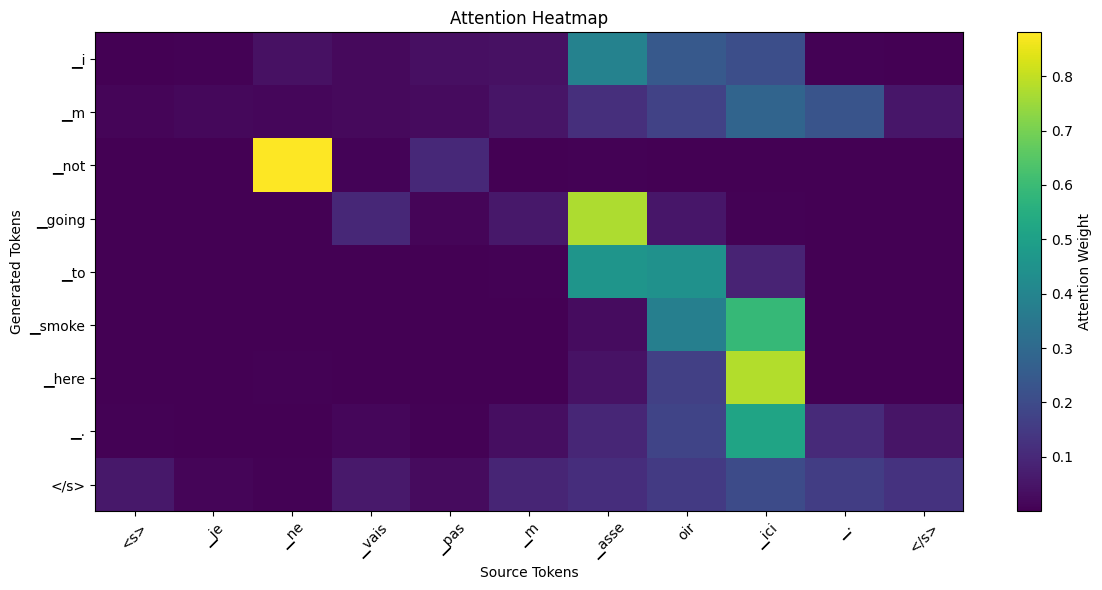

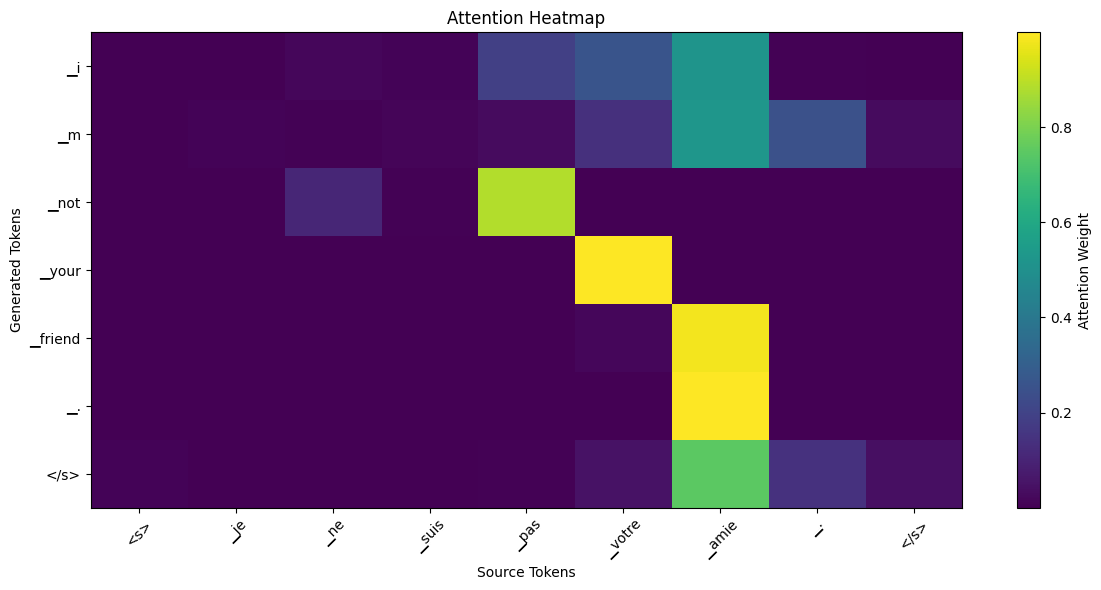

In [21]:
src, trg = next(iter(val_loader))
src = src.to(device)
src_lens = (src != PAD_IDX).sum(dim=1)

visualize_attentions(model,src,src_lens)

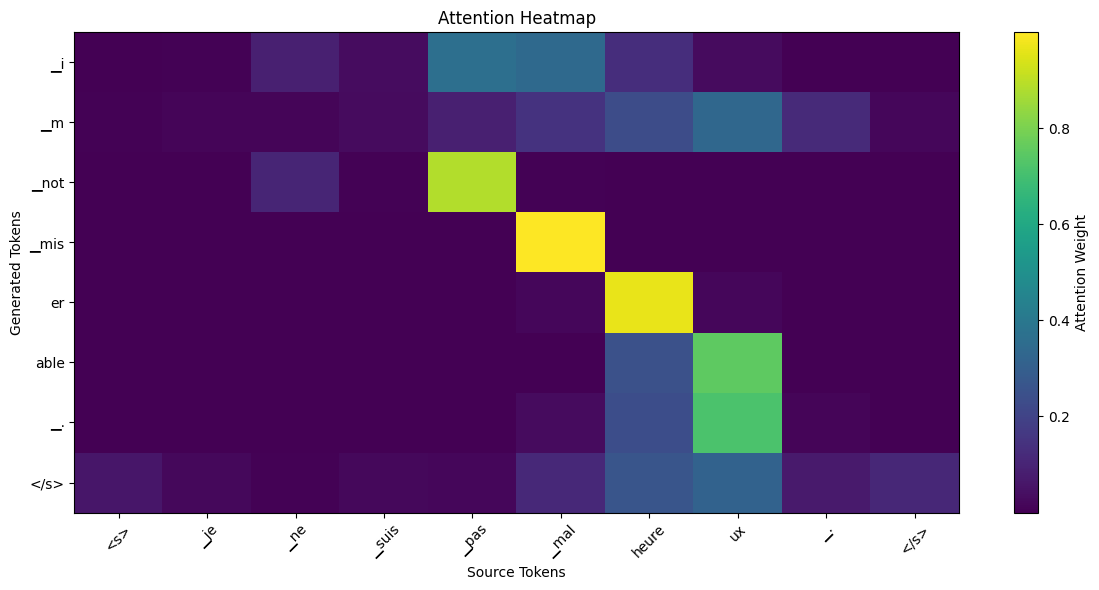

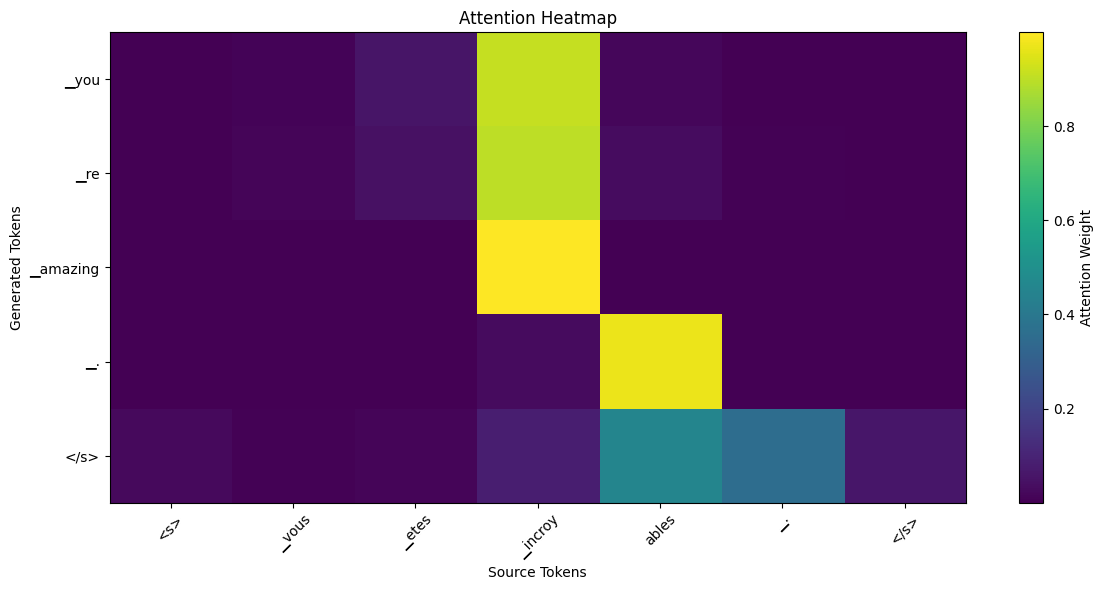

In [22]:
src, trg = next(iter(test_loader))
src = src.to(device)
src_lens = (src != PAD_IDX).sum(dim=1)

visualize_attentions(model,src,src_lens)


## Attention weights do not represent exact word-to-word translation.
### They represent how much each source hidden state contributes to predicting the next target token.  
### High attention means the model finds that source position most informative at that decoding moment, not necessarily its direct translation.    
### Attention maps may look misaligned because the training objective does not teach explicit alignment — attention is only learned as a side effect of minimizing translation loss.
